# 09e — Emission trend forecasting

This notebook extrapolates a historical emissions series into the
future via linear and log-linear (exponential) trend models, and — in
the final section — a state-space local-linear-trend model estimated by
Kalman filtering.

All 6 sections are self-contained illustrative worked examples (no
external data file — the emissions series are hardcoded numbers).
Sections 1, 2, 3, 4 use OLS (`quanttoolbox.stats.regression.ols.ols`);
section 6 uses the state-space/Kalman toolkit
(`quanttoolbox.econometrics.whittle.whittle_local_linear_trend`,
`quanttoolbox.econometrics.kalman.StateSpaceModel`/`kalman_filter`) —
this is the one section in this notebook that draws on `quanttoolbox`
rather than defining everything inline, since the underlying
state-space machinery belongs in a shared toolbox rather than being
reimplemented per-notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quanttoolbox.stats.regression.ols import ols
from quanttoolbox.econometrics.whittle import whittle_local_linear_trend
from quanttoolbox.econometrics.kalman import StateSpaceModel, kalman_filter

plt.rcParams["figure.dpi"] = 100

## 1. Linear trend, three ways to parameterize the intercept

A single OLS regression of an illustrative emissions series (2007-2020)
against time, refit with three different time-origin conventions
(`t0 = 0`, `t0 = 2007`, `t0 = 2020`) to show they give the same slope
and fitted values, just a reparameterized intercept — then a forecast
to 2025 using the `t0 = 2020` parameterization.


In [2]:
t = np.arange(2007, 2021)
CE = np.array([57.8, 58.4, 57.9, 55.1, 51.6, 48.3, 47.1, 46.1,
               44.4, 42.7, 41.4, 40.2, 41.9, 45.0])
y = CE
n = len(t)
c = np.ones(n)

x = np.column_stack([c, t])
res = ols(y, x)
print("sigma:", round(res.sigma, 4))
print("beta (t0=0):        ", np.round(res.beta, 4))

for t0 in (2007, 2020):
    x = np.column_stack([c, t - t0])
    beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
    print(f"beta (t0={t0}):   ", np.round(beta, 4))

beta1 = np.linalg.inv(np.column_stack([c, t]).T @ np.column_stack([c, t])) @ (np.column_stack([c, t]).T @ y)
t0 = 2020
beta_prime = np.array([beta1[0] + beta1[1] * t0, beta1[1]])
print("beta' (t0=2020, reparameterized from beta1):", np.round(beta_prime, 4))

x = np.column_stack([c, t - 2020])
beta3 = np.linalg.inv(x.T @ x) @ (x.T @ y)
t_forecast = 2025
CE_forecast = beta3[0] + beta3[1] * (t_forecast - 2020)
print(f"\nForecast CE({t_forecast}) = {CE_forecast:.2f}")

sigma: 2.483
beta (t0=0):         [ 2.9704303e+03 -1.4512000e+00]
beta (t0=2007):    [57.8543 -1.4512]
beta (t0=2020):    [38.9886 -1.4512]
beta' (t0=2020, reparameterized from beta1): [38.9886 -1.4512]

Forecast CE(2025) = 31.73


## 2. In-sample fit vs. out-of-sample linear forecast

Two ways to extend the fitted linear trend beyond the sample: keep the
regression's own fitted intercept/slope (`Forecast`), or re-anchor the
line to pass exactly through the last observed point while keeping the
same slope (`Forecast (rescaled)`) — the two coincide at `t=2020` by
construction and diverge afterward only through the intercept, not the
slope.


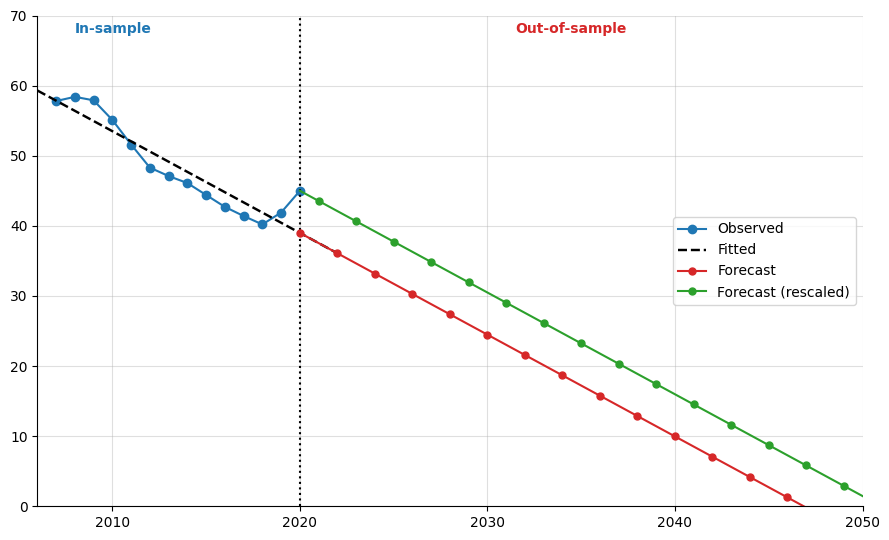

In [3]:
t0 = 2020
x = np.column_stack([np.ones(n), t - t0])
beta = np.linalg.inv(x.T @ x) @ (x.T @ y)
beta_prime = np.array([CE[-1], beta[1]])

x_ols = np.arange(2006, 2023)
y_ols = beta[0] + beta[1] * (x_ols - t0)

x_hat = np.arange(2020, 2051)
y_hat1 = beta[0] + beta[1] * (x_hat - t0)
y_hat2 = beta_prime[0] + beta_prime[1] * (x_hat - t0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(t, CE, "-o", color="tab:blue", markersize=6, linewidth=1.5, label="Observed")
ax.plot(x_ols, y_ols, "--", color="black", linewidth=1.75, label="Fitted")
ax.axvline(2020, linestyle=":", color="black", linewidth=1.5)
ax.plot(x_hat, y_hat1, "o-", color="tab:red", markersize=5, linewidth=1.5,
        markevery=2, label="Forecast")
ax.plot(x_hat, y_hat2, "-o", color="tab:green", markersize=5, linewidth=1.5,
        markevery=(1, 2), label="Forecast (rescaled)")
ax.text(2008, 67.5, "In-sample", fontsize=10, color="tab:blue", fontweight="bold")
ax.text(2031.5, 67.5, "Out-of-sample", fontsize=10, color="tab:red", fontweight="bold")
ax.set_xticks(range(2000, 2051, 10)); ax.set_xlim(2006, 2050)
ax.set_ylim(0, 70)
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10, loc="center right")
plt.tight_layout()
plt.show()

## 3. Linear vs. log-linear (exponential) trend forecast

The same series, now compared against a log-linear (constant
proportional decline) fit. `CE_t0_hat` reports both the raw and the
lognormal-bias-corrected level estimate at `t0`
($\exp(\hat\beta_0)$ vs. $\exp(\hat\beta_0 + \sigma^2/2)$).


beta (log): [ 3.68   -0.0295]
sigma: 0.05
CE(t0) estimate [raw, bias-corrected]: [39.65 39.7 ]


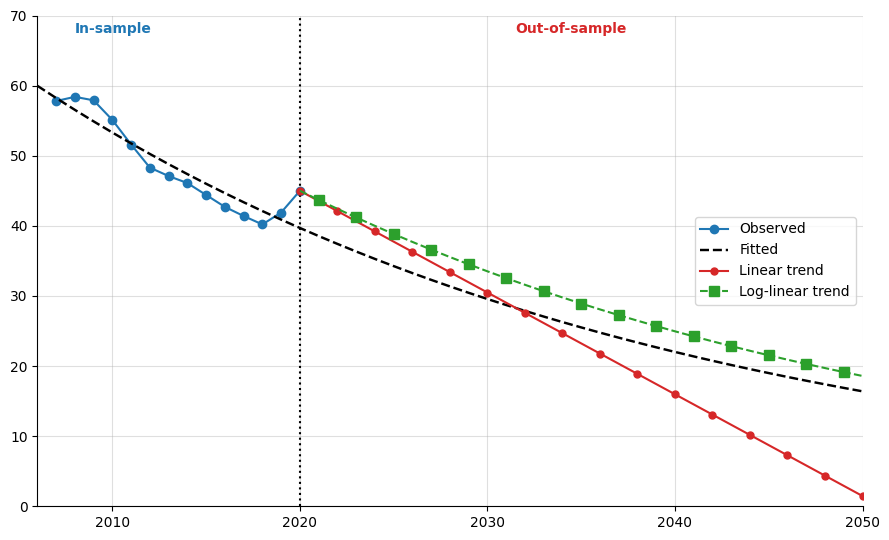

In [4]:
t0 = 2020
x = np.column_stack([np.ones(n), t - t0])
beta_lin = np.linalg.inv(x.T @ x) @ (x.T @ y)
beta_linear = np.array([CE[-1], beta_lin[1]])

x_hat = np.arange(2020, 2051)
y_hat1 = beta_linear[0] + beta_linear[1] * (x_hat - t0)

y_log = np.log(CE)
res_log = ols(y_log, x)
beta_log = res_log.beta
sigma = res_log.sigma
sigma2 = sigma ** 2
print("beta (log):", np.round(beta_log, 4))
print("sigma:", round(sigma, 4))

CE_t0_hat = np.array([np.exp(beta_log[0]), np.exp(beta_log[0] + 0.5 * sigma2)])
print("CE(t0) estimate [raw, bias-corrected]:", np.round(CE_t0_hat, 2))

y_hat2 = CE[-1] * np.exp(beta_log[1] * (x_hat - t0))
x_log = np.arange(2006, 2073)
y_log_curve = np.exp(beta_log[0] + 0.5 * sigma2) * np.exp(beta_log[1] * (x_log - t0))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(t, CE, "-o", color="tab:blue", markersize=6, linewidth=1.5, label="Observed")
ax.axvline(2020, linestyle=":", color="black", linewidth=1.5)
ax.plot(x_log, y_log_curve, "--", color="black", linewidth=1.75, label="Fitted")
ax.plot(x_hat, y_hat1, "-o", color="tab:red", markersize=5, linewidth=1.5,
        markevery=2, label="Linear trend")
ax.plot(x_hat, y_hat2, "--s", color="tab:green", markersize=7, linewidth=1.5,
        markevery=(1, 2), label="Log-linear trend")
ax.text(2008, 67.5, "In-sample", fontsize=10, color="tab:blue", fontweight="bold")
ax.text(2031.5, 67.5, "Out-of-sample", fontsize=10, color="tab:red", fontweight="bold")
ax.set_xticks(range(2000, 2051, 10)); ax.set_xlim(2006, 2050)
ax.set_ylim(0, 70)
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10, loc="center right")
plt.tight_layout()
plt.show()

## 4. Four illustrative emissions trajectories

Linear vs. log-linear trend extrapolation applied to four different
illustrative 2010-2020 series shaped to represent different transition
trajectories: accelerating growth, plateauing growth, a slow decline,
and a fast decline that eventually crosses zero (where the log-linear
fit is undefined/misleading — shown anyway to make that exact point
visually).


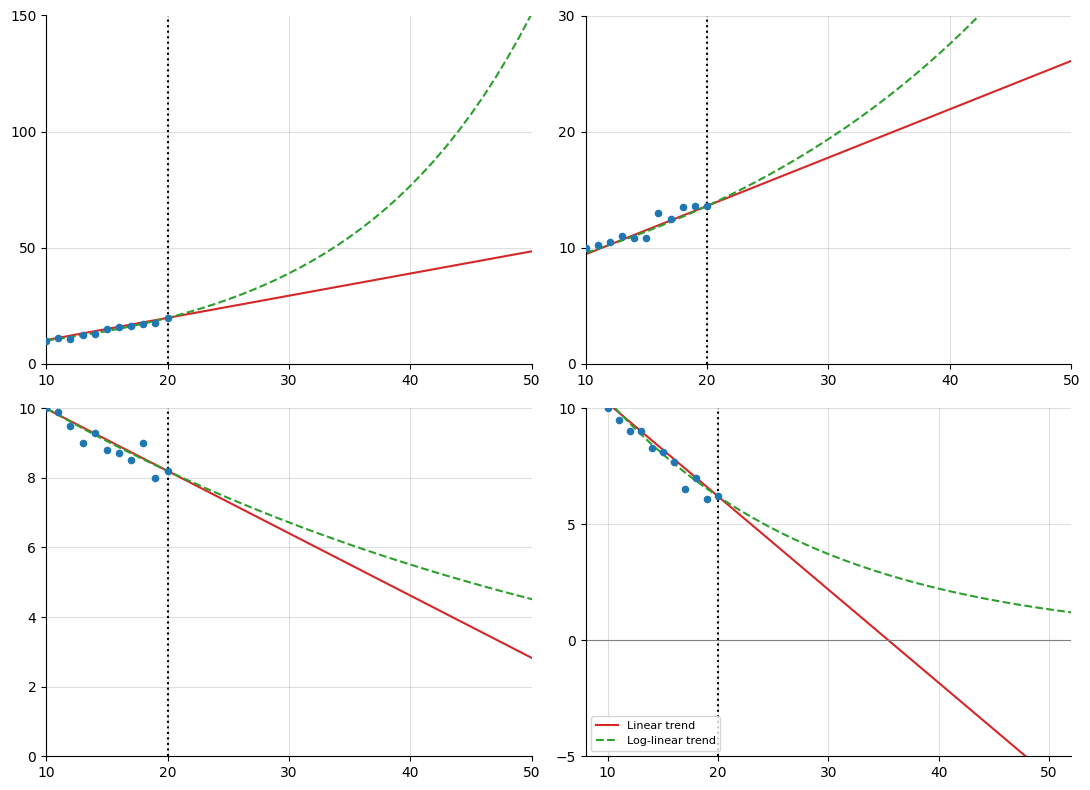

In [5]:
t4 = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])
CE1 = np.array([10.0, 11.1, 10.5, 12.5, 13.0, 14.8, 16.0, 16.5, 17.0, 17.5, 19.8])
CE2 = np.array([10.0, 10.2, 10.5, 11.0, 10.8, 10.8, 13.0, 12.5, 13.5, 13.6, 13.6])
CE3 = np.array([10.0, 9.9, 9.5, 9.0, 9.3, 8.8, 8.7, 8.5, 9.0, 8.0, 8.2])
CE4 = np.array([10.0, 9.5, 9.0, 9.0, 8.3, 8.1, 7.7, 6.5, 7.0, 6.1, 6.2])
CE_panels = [CE1, CE2, CE3, CE4]

t0 = 2020
x = np.column_stack([np.ones(len(t4)), t4 - t0])
x_hat = np.arange(2010, 2061)

ylims = [(0, 150), (0, 30), (0, 10.01), (-5, 10.01)]
yticks = [range(0, 151, 50), range(0, 31, 10), np.arange(0, 10.01, 2), np.arange(-5, 10.01, 5)]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for iter_, (ax, CE_i) in enumerate(zip(axes.flat, CE_panels), start=1):
    beta_linear = (np.linalg.inv(x.T @ x) @ (x.T @ CE_i))[1]
    beta_log = (np.linalg.inv(x.T @ x) @ (x.T @ np.log(CE_i)))[1]

    y_hat_linear = CE_i[-1] + beta_linear * (x_hat - t0)
    y_hat_log = CE_i[-1] * np.exp(beta_log * (x_hat - t0))

    ax.scatter(t4, CE_i, color="tab:blue", s=20, zorder=3)
    ax.axvline(2020, linestyle=":", color="black", linewidth=1.5)
    ax.plot(x_hat, y_hat_linear, "-", color="tab:red", linewidth=1.5, label="Linear trend")
    ax.plot(x_hat, y_hat_log, "--", color="tab:green", linewidth=1.5, label="Log-linear trend")

    ax.set_xlim(2010, 2050); ax.set_xticks(range(2010, 2051, 10))
    ax.set_xticklabels(["10", "20", "30", "40", "50"])
    ax.set_ylim(*ylims[iter_ - 1]); ax.set_yticks(list(yticks[iter_ - 1]))
    ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
    if iter_ == 4:
        ax.set_xlim(2008.0, 2052)
        ax.axhline(0, color="grey", linewidth=0.8)
        ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

## 5. Compound-growth reference table

A small reference table: $R(\gamma, t) = e^{\gamma t}$, the compound
growth/decline factor for a range of constant annual rates $\gamma$
(0% to 10%) over several horizons $t$ — useful for sanity-checking the
implied compounding behind any of the log-linear trend rates fitted
above.


In [6]:
gamma1 = np.round(np.arange(0, 0.101, 0.01), 2)
t_grid = np.array([1, 5, 10, 15, 20, 25, 30])
R = np.exp(np.outer(gamma1, t_grid))

df5 = pd.DataFrame(R.T, index=t_grid, columns=[f"{g:.0%}" for g in gamma1])
df5.index.name = "t (years)"
df5.round(2)

,0%,1%,2%,3%,4%,5%,6%,7%,8%,9%,10%
t (years),,,,,,,,,,,
1,1.0,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.11
5,1.0,1.05,1.11,1.16,1.22,1.28,1.35,1.42,1.49,1.57,1.65
10,1.0,1.11,1.22,1.35,1.49,1.65,1.82,2.01,2.23,2.46,2.72
15,1.0,1.16,1.35,1.57,1.82,2.12,2.46,2.86,3.32,3.86,4.48
20,1.0,1.22,1.49,1.82,2.23,2.72,3.32,4.06,4.95,6.05,7.39
25,1.0,1.28,1.65,2.12,2.72,3.49,4.48,5.75,7.39,9.49,12.18
30,1.0,1.35,1.82,2.46,3.32,4.48,6.05,8.17,11.02,14.88,20.09


## 6. Growing-window OLS slope vs. Kalman-filtered local-linear-trend slope

Two ways to track how the trend's own slope is evolving over time: a
growing-window OLS re-fit through each point (which reacts slowly and
is undefined for the first two points), and a genuinely time-varying
local-linear-trend state-space model estimated by Whittle likelihood
and filtered with the Kalman filter — a smooth, continuously-updating
slope estimate `a_filt[:,1]` alongside the filtered trend level
`a_filt[:,0]`.

Note: with only 14 annual observations, the 3-parameter Whittle
optimization (`sigma_epsilon`, `sigma_eta`, `sigma_zeta`) does not fully
converge and its own asymptotic standard errors are not meaningful on a
sample this short -- flagged here rather than hidden, since it's an
honest small-sample limitation of the method. The point estimates and
the resulting filtered slope/trend are still usable as an illustration
of the technique.


Whittle estimates [sigma_epsilon, sigma_eta, sigma_zeta]: [0.0102 0.8252 0.9011]
Converged: False (small-sample optimization; see note above)


,Year,CE,Slope (growing-window OLS),Slope (Kalman local-linear-trend),Filtered trend level
0,2007,57.8,NaN,0.0000,57.8000
1,2008,58.4,NaN,0.3263,58.4000
2,2009,57.9,0.0500,-0.1980,57.9000
3,2010,55.1,-0.8600,-1.8795,55.1001
4,2011,51.6,-1.5700,-2.9291,51.6001
5,2012,48.3,-2.0200,-3.1695,48.3000
6,2013,47.1,-2.0929,-1.8935,47.0999
7,2014,46.1,-2.0321,-1.3145,46.1000
8,2015,44.4,-1.9817,-1.5642,44.4000
9,2016,42.7,-1.9406,-1.6522,42.7000


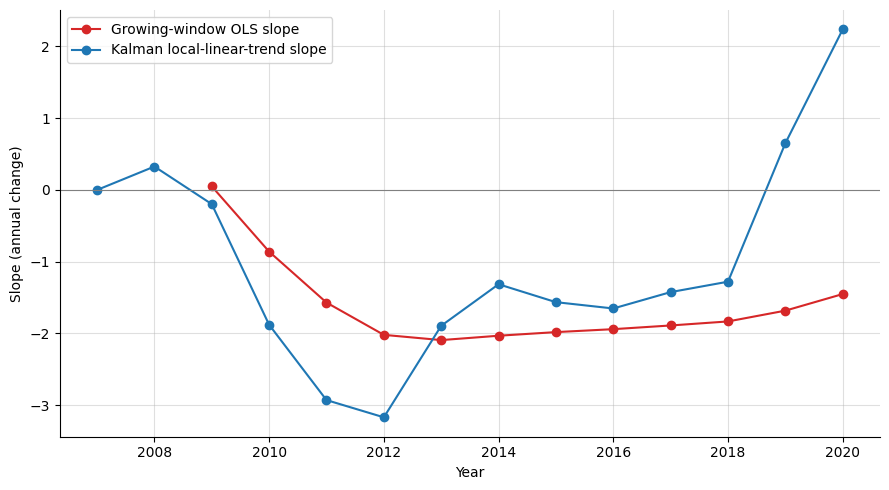

In [7]:
t6 = np.arange(2007, 2021)
CE6 = np.array([57.8, 58.4, 57.9, 55.1, 51.6, 48.3, 47.1, 46.1,
                44.4, 42.7, 41.4, 40.2, 41.9, 45.0])
n = len(t6)
slope = np.full((n, 2), np.nan)

for iter_ in range(2, n):
    tt = t6[: iter_ + 1]
    xx = np.column_stack([np.ones(len(tt)), tt])
    yy = CE6[: iter_ + 1]
    beta_ols = np.linalg.inv(xx.T @ xx) @ (xx.T @ yy)
    slope[iter_, 0] = beta_ols[1]

# Whittle-estimated local-linear-trend variances, then Kalman filter.
# With only 14 observations (12 valid twice-differenced points feeding a
# 3-parameter variance-decomposition likelihood), the optimizer's own
# Hessian-based standard errors are not reliable (a non-PSD inverse Hessian
# is expected on a series this short) -- np.errstate suppresses the
# resulting sqrt-of-negative RuntimeWarning locally; the point estimates
# (theta) themselves are unaffected and are what's used below.
with np.errstate(invalid="ignore"):
    whittle_res = whittle_local_linear_trend(CE6, sv := np.ones(3))
sigma_epsilon, sigma_eta, sigma_zeta = whittle_res.theta
print("Whittle estimates [sigma_epsilon, sigma_eta, sigma_zeta]:", np.round(whittle_res.theta, 4))
print("Converged:", whittle_res.converged, "(small-sample optimization; see note above)")

ssm = StateSpaceModel(
    z=np.array([[1.0, 0.0]]),
    d=np.array([0.0]),
    h=np.array([[sigma_epsilon ** 2]]),
    t=np.array([[1.0, 1.0], [0.0, 1.0]]),
    c=np.array([0.0, 0.0]),
    r=np.eye(2),
    q=np.diag([sigma_eta ** 2, sigma_zeta ** 2]),
)
a0 = np.array([CE6[0], 0.0])
p0 = np.zeros((2, 2))
kf = kalman_filter(ssm, CE6.reshape(-1, 1), a0, p0)

slope[:, 1] = kf.a_filt[:, 1]
trend_level = kf.a_filt[:, 0]

df6 = pd.DataFrame({
    "Year": t6, "CE": CE6,
    "Slope (growing-window OLS)": slope[:, 0],
    "Slope (Kalman local-linear-trend)": slope[:, 1],
    "Filtered trend level": trend_level,
})
display(df6.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t6, slope[:, 0], "o-", color="tab:red", label="Growing-window OLS slope")
ax.plot(t6, slope[:, 1], "o-", color="tab:blue", label="Kalman local-linear-trend slope")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Year"); ax.set_ylabel("Slope (annual change)")
ax.grid(alpha=0.4); ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()